# Лабораторная работа 5  
## Тестирование качества работы моделей машинного обучения

**Цель:** применить `pytest` для автоматического тестирования качества работы модели линейной регрессии на разных датасетах и обнаружить проблему на датасете с шумами.

В ноутбуке создаются:
- три датасета с качественными линейными данными;
- один датасет с шумом в части данных;
- модель линейной регрессии, обученная на одном качественном датасете;
- автоматические тесты `pytest`, которые проверяют качество предсказаний модели.


In [4]:
%pip install numpy pandas matplotlib scikit-learn joblib pytest

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Чтобы результаты повторялись при каждом запуске
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Каталог для результатов лабораторной работы
LAB_DIR = Path("lab5")
LAB_DIR.mkdir(exist_ok=True)

LAB_DIR


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/12.3 MB 11.1 MB/s eta 0:00:01
   --------------------- ------------------ 6.6/12.3 MB 17.6 MB/s eta 0:00:01
   ------------------------------------- -- 11.5/12.3 MB 19.7 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 17.6 MB/s  0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------------------ --------------------- 4.5/9.8 MB 24.7 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.8 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 19.3 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.2 MB 18.0 MB/s eta 0:00:01
   -------------------------------

WindowsPath('lab5')

## 1. Создание трёх качественных датасетов

Сделаем три набора данных, которые хорошо описываются линейной зависимостью:

\[
y = kx + b + \varepsilon
\]

где \(\varepsilon\) — небольшой случайный шум.


In [5]:
def make_clean_dataset(k=1.0, b=0.0, noise_level=0.7, n=100, random_state=42):
    """Создаёт качественный линейный датасет."""
    rng = np.random.default_rng(random_state)
    xs = np.linspace(0, 10, n)
    noise = rng.normal(0, noise_level, n)
    ys = k * xs + b + noise
    return pd.DataFrame({"x": xs, "y": ys})


clean_1 = make_clean_dataset(k=1.0, b=0.0, noise_level=0.55, random_state=1)
clean_2 = make_clean_dataset(k=1.0, b=0.2, noise_level=0.60, random_state=2)
clean_3 = make_clean_dataset(k=0.95, b=0.4, noise_level=0.65, random_state=3)

clean_1.to_csv(LAB_DIR / "clean_1.csv", index=False)
clean_2.to_csv(LAB_DIR / "clean_2.csv", index=False)
clean_3.to_csv(LAB_DIR / "clean_3.csv", index=False)

clean_1.head()

,x,y
0,0.00000,0.190071
1,0.10101,0.552900
2,0.20202,0.383761
3,0.30303,-0.413706
4,0.40404,0.901986


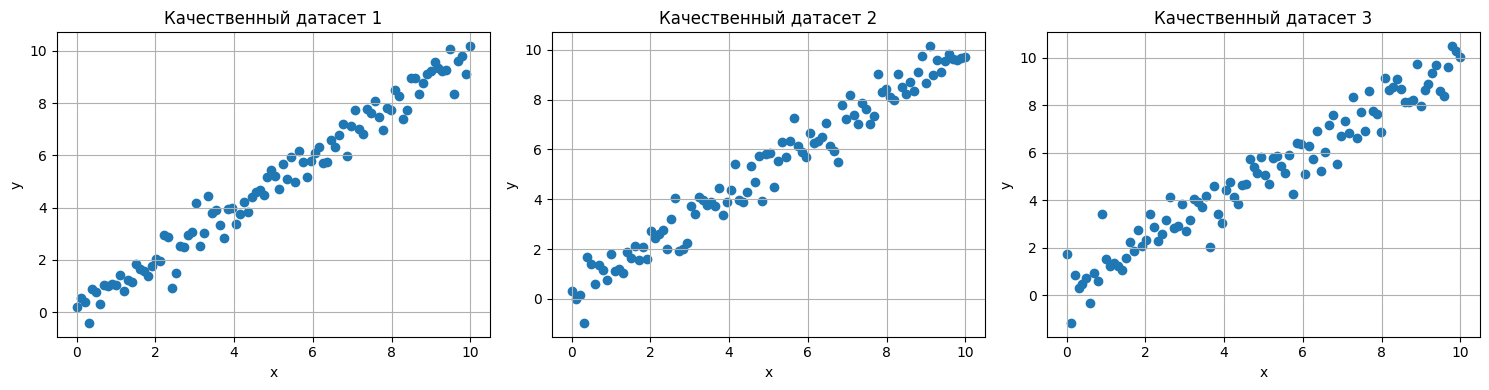

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (clean_1, "Качественный датасет 1"),
    (clean_2, "Качественный датасет 2"),
    (clean_3, "Качественный датасет 3"),
]

for ax, (data, title) in zip(axes, datasets):
    ax.scatter(data["x"], data["y"])
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)

plt.tight_layout()
plt.savefig(LAB_DIR / "clean_datasets.png", dpi=150)
plt.show()

## 2. Обучение модели линейной регрессии

Обучим модель на первом качественном датасете.


In [7]:
X_train = clean_1[["x"]]
y_train = clean_1["y"]

model = LinearRegression()
model.fit(X_train, y_train)

print("Коэффициент k:", model.coef_[0])
print("Свободный член b:", model.intercept_)

joblib.dump(model, LAB_DIR / "linear_model.joblib")

Коэффициент k: 0.990126061478819
Свободный член b: 0.00888302590578327


['lab5\\linear_model.joblib']

In [8]:
def evaluate_model(model, data):
    """Возвращает MSE и R2 для модели на датасете."""
    X = data[["x"]]
    y_true = data["y"]
    y_pred = model.predict(X)

    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, r2, y_pred


for name, data in [
    ("clean_1", clean_1),
    ("clean_2", clean_2),
    ("clean_3", clean_3),
]:
    mse, r2, _ = evaluate_model(model, data)
    print(f"{name}: MSE = {mse:.3f}, R2 = {r2:.3f}")

clean_1: MSE = 0.219, R2 = 0.974
clean_2: MSE = 0.380, R2 = 0.956
clean_3: MSE = 0.520, R2 = 0.936


## 3. Создание датасета с шумом

Теперь создадим датасет, в котором часть значений `y` будет искусственно искажена. Это имитирует проблему в данных: выбросы, ошибки измерения или некорректные записи.


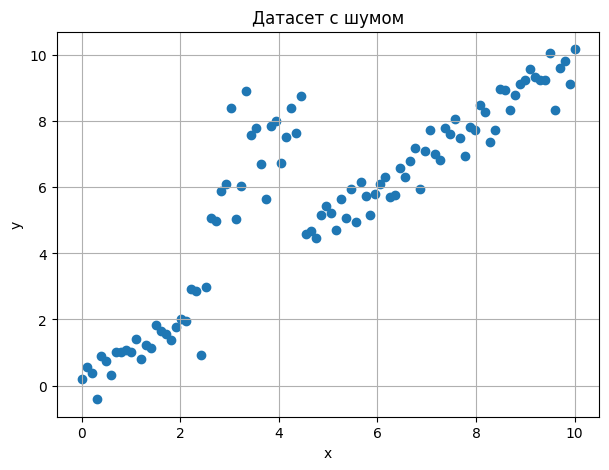

In [9]:
def make_noisy_dataset(base_data, start=25, end=45, multiplier=2.0):
    """Создаёт датасет с шумом: часть значений y умножается на multiplier."""
    noisy = base_data.copy()
    noisy.loc[start:end-1, "y"] *= multiplier
    return noisy


noisy = make_noisy_dataset(clean_1, start=25, end=45, multiplier=2.0)
noisy.to_csv(LAB_DIR / "noisy.csv", index=False)

plt.figure(figsize=(7, 5))
plt.scatter(noisy["x"], noisy["y"])
plt.title("Датасет с шумом")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.savefig(LAB_DIR / "noisy_dataset.png", dpi=150)
plt.show()

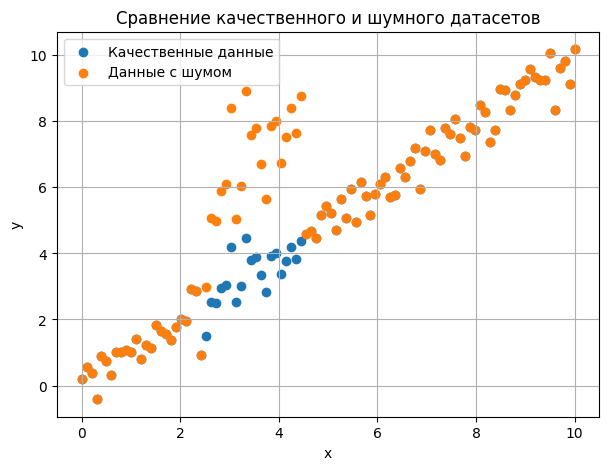

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(clean_1["x"], clean_1["y"], label="Качественные данные")
plt.scatter(noisy["x"], noisy["y"], label="Данные с шумом")

plt.title("Сравнение качественного и шумного датасетов")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.savefig(LAB_DIR / "clean_vs_noisy.png", dpi=150)
plt.show()

## 4. Проверка качества модели на всех датасетах

Для качественных данных ожидаем высокий коэффициент детерминации \(R^2\).  
Для датасета с шумом качество должно заметно ухудшиться.


In [11]:
results = []

for name, data in [
    ("clean_1", clean_1),
    ("clean_2", clean_2),
    ("clean_3", clean_3),
    ("noisy", noisy),
]:
    mse, r2, y_pred = evaluate_model(model, data)
    results.append({"dataset": name, "mse": mse, "r2": r2})

results_df = pd.DataFrame(results)
results_df.to_csv(LAB_DIR / "quality_report.csv", index=False)
results_df

,dataset,mse,r2
0,clean_1,0.218529,0.974451
1,clean_2,0.379830,0.955838
2,clean_3,0.519777,0.935671
3,noisy,2.682603,0.689264


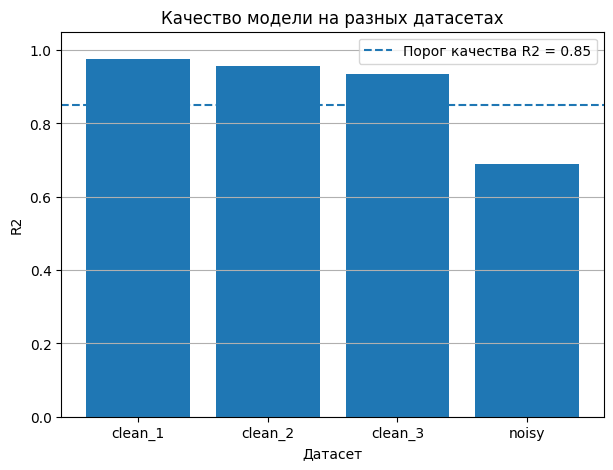

In [12]:
plt.figure(figsize=(7, 5))

plt.bar(results_df["dataset"], results_df["r2"])
plt.axhline(0.85, linestyle="--", label="Порог качества R2 = 0.85")

plt.title("Качество модели на разных датасетах")
plt.xlabel("Датасет")
plt.ylabel("R2")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y")

plt.savefig(LAB_DIR / "r2_comparison.png", dpi=150)
plt.show()

## 5. Создание файла с тестами pytest

В тестах используется порог качества:

```python
R2_THRESHOLD = 0.85
```

Логика тестирования:
- на качественных датасетах модель должна иметь `R2 >= 0.85`;
- на шумном датасете модель должна показать качество ниже порога, значит проблема в данных обнаружена.


In [13]:
%%writefile lab5/test_model_quality.py
from pathlib import Path

import joblib
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score


LAB_DIR = Path(__file__).parent
R2_THRESHOLD = 0.85


def load_model():
    return joblib.load(LAB_DIR / "linear_model.joblib")


def load_dataset(filename):
    return pd.read_csv(LAB_DIR / filename)


def evaluate(model, data):
    X = data[["x"]]
    y_true = data["y"]
    y_pred = model.predict(X)

    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, r2


def test_model_quality_on_clean_1():
    model = load_model()
    data = load_dataset("clean_1.csv")
    mse, r2 = evaluate(model, data)

    assert r2 >= R2_THRESHOLD, f"Качество на clean_1 слишком низкое: R2={r2:.3f}, MSE={mse:.3f}"


def test_model_quality_on_clean_2():
    model = load_model()
    data = load_dataset("clean_2.csv")
    mse, r2 = evaluate(model, data)

    assert r2 >= R2_THRESHOLD, f"Качество на clean_2 слишком низкое: R2={r2:.3f}, MSE={mse:.3f}"


def test_model_quality_on_clean_3():
    model = load_model()
    data = load_dataset("clean_3.csv")
    mse, r2 = evaluate(model, data)

    assert r2 >= R2_THRESHOLD, f"Качество на clean_3 слишком низкое: R2={r2:.3f}, MSE={mse:.3f}"


def test_noisy_dataset_problem_is_detected():
    model = load_model()
    data = load_dataset("noisy.csv")
    mse, r2 = evaluate(model, data)

    assert r2 < R2_THRESHOLD, (
        f"Проблема с шумом не обнаружена: R2={r2:.3f}, MSE={mse:.3f}. "
        f"Ожидалось, что качество будет ниже порога {R2_THRESHOLD}."
    )


Writing lab5/test_model_quality.py


## 6. Запуск pytest

Запускаем тесты прямо из Jupyter Notebook с помощью команды `!pytest`.


In [14]:
!pytest -v lab5/test_model_quality.py

============================= test session starts =============================
platform win32 -- Python 3.13.7, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\buravov\study\Mlops-practies\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\buravov\study\Mlops-practies\lab5
collecting ... collected 4 items

lab5/test_model_quality.py::test_model_quality_on_clean_1 PASSED         [ 25%]
lab5/test_model_quality.py::test_model_quality_on_clean_2 PASSED         [ 50%]
lab5/test_model_quality.py::test_model_quality_on_clean_3 PASSED         [ 75%]
lab5/test_model_quality.py::test_noisy_dataset_problem_is_detected PASSED [100%]

============================== 4 passed in 1.24s ==============================


## Вывод

В ходе лабораторной работы:

1. Были созданы три качественных линейных датасета.
2. На одном качественном датасете была обучена модель линейной регрессии.
3. Был создан датасет с шумом, где часть значений `y` была искусственно искажена.
4. С помощью `pytest` были написаны автоматические тесты качества модели.
5. Тесты подтвердили, что на качественных данных модель работает хорошо.
6. Для шумного датасета тест обнаружил снижение качества модели ниже установленного порога `R2 = 0.85`.

Таким образом, автоматическое тестирование позволило обнаружить проблему в данных.
